##SETUP

In [ ]:
from datetime import date, datetime
from collections import defaultdict
from google.colab import userdata
import re

MISTRAL_API_KEY = userdata.get("mistral_kay")

from openai import OpenAI
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

#mistral uses the same format as OpenAI, so we can use the OpenAI SDK with it.
client = OpenAI(api_key=MISTRAL_API_KEY, base_url="https://api.mistral.ai/v1")
print('Client ready.')

GEN_MODEL = 'mistral-small-latest'   # single generator for ALL conditions
EMBED_MODEL = 'mistral-embed'

test = client.chat.completions.create(
    model=GEN_MODEL,
    messages=[{"role": "user", "content": "Reply with the single word: ready"}]
)
print('Generation model response:', test.choices[0].message.content.strip())

import time as _time
import random as _random

def call_with_retry(fn, max_retries=6, base_delay=2.0):
    #Wraps any Mistral API call (chat or embeddings) with exponential backoff on 429s
    for attempt in range(max_retries):
        try:
            return fn()
        except Exception as e:
            is_rate_limit = "429" in str(e) or "rate_limited" in str(e).lower() or "RateLimitError" in type(e).__name__
            if not is_rate_limit or attempt == max_retries - 1:
                raise
            wait = base_delay * (2 ** attempt) + _random.uniform(0, 1)
            print(f"  [Mistral 429, retrying in {wait:.1f}s (attempt {attempt + 1}/{max_retries})]")
            _time.sleep(wait)

_EMBED_CACHE = {}

def get_doc_embeddings(doc_texts):
    key = tuple(doc_texts)
    if key not in _EMBED_CACHE:
        resp = call_with_retry(lambda: client.embeddings.create(model=EMBED_MODEL, input=doc_texts))
        _EMBED_CACHE[key] = np.array([item.embedding for item in resp.data], dtype=np.float32)
    return _EMBED_CACHE[key]

Client ready.
Generation model response: Ready


##FETCHING REAL WORLD DATA & SUCCESSION SEED

In [ ]:
AS_OF_DATE = date(2025, 8, 15)

#a document is valid of the effective date is before the current day's date
def is_current(effective_date_str):
    d = datetime.strptime(effective_date_str, "%Y-%m-%d").date()
    return d <= AS_OF_DATE

In [ ]:
import requests
import time
import random

WIKI_EXTRACT_URL = "https://en.wikipedia.org/w/api.php"
WIKI_HEADERS = { "User-Agent": "RAG-Benchmark-Research/1.0 (contact: you@example.com) requests-python"}

MAX_RETRIES = 5
BASE_BACKOFF_SECONDS = 2.0
SLEEP_BETWEEN_REQUESTS = 1.0

#avoids re-fetching the same ceo's wikipedia page across multiple company/era entries
_WIKI_CACHE = {}

#extracts text snippets from wikipedia of a person (ceo)
def fetch_wikipedia_extract(title, sentences=10):
    if title in _WIKI_CACHE:
        return _WIKI_CACHE[title]

    params = {
        "action": "query",
        "prop": "extracts",
        "exsentences": sentences,
        "explaintext": 1,
        "titles": title,
        "format": "json",
        "redirects": 1,
    }

    extract = None
    for attempt in range(MAX_RETRIES):
        try:
            r = requests.get(WIKI_EXTRACT_URL, params=params, headers=WIKI_HEADERS, timeout=15)
            if r.status_code == 429 or r.status_code >= 500:
                retry_after = r.headers.get("Retry-After")
                wait = float(retry_after) if retry_after else BASE_BACKOFF_SECONDS * (2 ** attempt)
                wait += random.uniform(0, 0.5)
                print(f"  [wiki {r.status_code} for {title}, retrying in {wait:.1f}s "
                      f"(attempt {attempt + 1}/{MAX_RETRIES})]")
                time.sleep(wait)
                continue
            r.raise_for_status()
            pages = r.json()["query"]["pages"]
            page = next(iter(pages.values()))
            extract = page.get("extract", "").strip() or None
            break
        except Exception as e:
            print(f"  [wiki fetch failed for {title} (attempt {attempt + 1}/{MAX_RETRIES}): {e}]")
            time.sleep(BASE_BACKOFF_SECONDS * (2 ** attempt) + random.uniform(0, 0.5))

    if extract is None:
        print(f"  [wiki fetch permanently failed for {title} after {MAX_RETRIES} attempts]")
    _WIKI_CACHE[title] = extract
    return extract

#blueprint of the metadata to build documents for the corpus - each company contains data on the ceos that have served along with the dates they began their reign
CEO_SUCCESSION_SEED = [
    {"company": "Apple Inc.", "eras": [
        {"ceo": "Gil Amelio", "effective_date": "1996-02-02"},
        {"ceo": "Steve Jobs", "effective_date": "1997-07-09"},
        {"ceo": "Tim Cook", "effective_date": "2011-08-24"},
    ]},
    {"company": "Microsoft", "eras": [
        {"ceo": "Bill Gates", "effective_date": "1975-04-04"},
        {"ceo": "Steve Ballmer", "effective_date": "2000-01-13"},
        {"ceo": "Satya Nadella", "effective_date": "2014-02-04"},
    ]},
    {"company": "Amazon (company)", "eras": [
        {"ceo": "Jeff Bezos", "effective_date": "1994-07-05"},
        {"ceo": "Andy Jassy", "effective_date": "2021-07-05"},
    ]},
    {"company": "Google", "eras": [
        {"ceo": "Eric Schmidt", "effective_date": "2001-08-01"},
        {"ceo": "Larry Page", "effective_date": "2011-04-04"},
        {"ceo": "Sundar Pichai", "effective_date": "2015-08-10"},
    ]},
    {"company": "Twitter", "eras": [
        {"ceo": "Jack Dorsey", "effective_date": "2015-10-01"},
        {"ceo": "Parag Agrawal", "effective_date": "2021-11-29"},
        {"ceo": "Elon Musk", "effective_date": "2022-10-27"},
        {"ceo": "Linda Yaccarino", "effective_date": "2023-06-05"},
    ]},
    {"company": "Tesla, Inc.", "eras": [
        {"ceo": "Martin Eberhard", "effective_date": "2003-07-01"},
        {"ceo": "Elon Musk", "effective_date": "2008-10-01"}
    ]},
    {"company": "The Walt Disney Company", "eras": [
        {"ceo": "Michael Eisner", "effective_date": "1984-09-22"},
        {"ceo": "Bob Iger", "effective_date": "2005-10-01"},
        {"ceo": "Bob Chapek", "effective_date": "2020-02-25"},
        {"ceo": "Bob Iger", "effective_date": "2022-11-20"},
    ]},
    {"company": "Starbucks", "eras": [
        {"ceo": "Howard Schultz", "effective_date": "1986-01-01"},
        {"ceo": "Kevin Johnson", "effective_date": "2017-04-03"},
        {"ceo": "Howard Schultz", "effective_date": "2022-04-04"},
        {"ceo": "Laxman Narasimhan", "effective_date": "2023-03-20"},
        {"ceo": "Brian Niccol", "effective_date": "2024-09-09"},
    ]},
    {"company": "Boeing", "eras": [
        {"ceo": "Dennis Muilenburg", "effective_date": "2015-07-01"},
        {"ceo": "David Calhoun", "effective_date": "2020-01-13"},
        {"ceo": "Kelly Ortberg", "effective_date": "2024-08-08"},
    ]},

    {"company": "IBM", "eras": [
        {"ceo": "Louis V. Gerstner Jr.", "effective_date": "1993-04-01"},
        {"ceo": "Sam Palmisano", "effective_date": "2002-03-01"},
        {"ceo": "Ginni Rometty", "effective_date": "2012-01-01"},
        {"ceo": "Arvind Krishna", "effective_date": "2020-04-06"},
    ]},
    {"company": "Intel", "eras": [
        {"ceo": "Craig Barrett", "effective_date": "1998-05-01"},
        {"ceo": "Paul Otellini", "effective_date": "2005-05-18"},
        {"ceo": "Brian Krzanich", "effective_date": "2013-05-16"},
        {"ceo": "Bob Swan", "effective_date": "2019-01-31"},
        {"ceo": "Pat Gelsinger", "effective_date": "2021-02-15"},
    ]},
    {"company": "Uber", "eras": [
        {"ceo": "Travis Kalanick", "effective_date": "2010-03-01"},
        {"ceo": "Dara Khosrowshahi", "effective_date": "2017-08-30"},
    ]},

    {"company": "eBay", "eras": [
        {"ceo": "Meg Whitman", "effective_date": "1998-02-01"},
        {"ceo": "John Donahoe", "effective_date": "2008-03-31"},
        {"ceo": "Devin Wenig", "effective_date": "2015-07-01"},
        {"ceo": "Jamie Iannone", "effective_date": "2020-04-27"},
    ]},

    {"company": "General Motors", "eras": [
        {"ceo": "Rick Wagoner", "effective_date": "2000-06-01"},
        {"ceo": "Fritz Henderson", "effective_date": "2009-03-30"},
        {"ceo": "Dan Akerson", "effective_date": "2010-09-01"},
        {"ceo": "Mary Barra", "effective_date": "2014-01-15"},
    ]},

    {"company": "Netflix", "eras": [
        {"ceo": "Reed Hastings", "effective_date": "1997-08-29"},
        {"ceo": "Ted Sarandos", "effective_date": "2020-07-16"},
    ]},

    {"company": "Nike, Inc.", "eras": [
        {"ceo": "Mark Parker", "effective_date": "2006-01-01"},
        {"ceo": "John Donahoe", "effective_date": "2020-01-13"},
        {"ceo": "Elliott Hill", "effective_date": "2024-10-14"},
    ]},
]

print(f"Seed list: {len(CEO_SUCCESSION_SEED)} companies, "
      f"{sum(len(c['eras']) for c in CEO_SUCCESSION_SEED)} CEO-eras total.")

Seed list: 16 companies, 53 CEO-eras total.


## BUILDING DOCUMENTS FROM WIKIPEDIA API

In [ ]:
#text extracted from a CEO's wikipedia page
def build_real_document(company, ceo, effective_date):
    person_extract = fetch_wikipedia_extract(ceo, sentences=6)
    if not person_extract:
        return None
    doc_text = (
        f"Start date as {ceo} of {company}: {effective_date}"
        f"{person_extract}"
        )

    # A document of a single CEO of a company containing - text extract, company, name, start date of reign, doc type: real or fake (i.e. containing contradictory documents)
    return {
        "text": doc_text,
        "company": company,
        "ceo": ceo,
        "effective_date": effective_date,
        "doc_type": "primary",
        }

#builds corpus from wikipedia using text extracts and metadata compiled in build_real_document
def build_corpus_from_wikipedia(seed=CEO_SUCCESSION_SEED, sleep_between=SLEEP_BETWEEN_REQUESTS, min_success_rate=0.7):
    docs = []
    failures = 0
    total = sum(len(c["eras"]) for c in seed) #eras denote the toal number of real documents

    for entry in seed:
        company = entry["company"]
        for era in entry["eras"]:
            d = build_real_document(
                company,
                era["ceo"],
                era["effective_date"]
            )
            if d is None:
                failures += 1
                continue
            docs.append(d)
            time.sleep(sleep_between)
    success_rate = len(docs) / total if total else 0.0
    print(f"Fetched {len(docs)} real documents from Wikipedia "
          f"({failures} failures, {success_rate:.0%} success rate).")

    if success_rate < min_success_rate:
        print(f"  success rate {success_rate:.0%} is below the {min_success_rate:.0%} "
              f"try again")
        return None
    return docs if docs else None

## STALE DUPLICATE PARAPHRASES

In [ ]:
#6 total paraphrase templates selected at random each trial. total number selected when configuring axes
PARAPHRASE_TEMPLATES = [
    "As previously disclosed in company filings, {ceo} has served as Chief "
    "Executive Officer of {company} since {date}.",
    "News wire recap: {company} confirmed that {ceo} took over as CEO in {year}, "
    "a leadership change widely covered at the time.",
    "Company bio archive: {ceo} — Chief Executive Officer of {company}, appointed {date}.",
    "Analyst note (archived): Under CEO {ceo}, who assumed the role at {company} "
    "in {year}, the firm pursued its strategy for that period.",
    "Historical press summary: {company} announced the appointment of {ceo} as "
    "its chief executive, effective {date}.",
    "Corporate governance record: {ceo} is listed as {company}'s CEO of record "
    "as of the {year} fiscal year filing.",
]


def make_paraphrases(para_doc, n=3, rng=None):
    rng = rng or random
    year = para_doc["effective_date"][:4]
    templates = rng.sample(PARAPHRASE_TEMPLATES, k=min(n, len(PARAPHRASE_TEMPLATES)))
    para = []
    for tmpl in templates:
        text = tmpl.format(ceo=para_doc["ceo"], company=para_doc["company"], date=para_doc["effective_date"], year=year)
        para.append({
            "text": text,
            "company": para_doc["company"],
            "ceo": para_doc["ceo"],
            "effective_date": para_doc["effective_date"],
            "doc_type": "stale_paraphrase",
            "future_relative_to_query": para_doc.get("future_relative_to_query", False),
        })
    return para

## CONTRADICTORY DATA

In [ ]:
CONTRADICTION_SEED = [
    ("Apple Inc.", "Tim Cook", "2011-08-01"),                # false: Tim Cook actually correct date differs by weeks
    ("Microsoft", "Bill Gates", "2015-01-01"),               # false: Gates not CEO in 2015
    ("Amazon (company)", "Jeff Bezos", "2022-01-01"),        # false: Bezos stepped down mid-2021
    ("Google", "Larry Page", "2020-01-01"),                  # false: Pichai was CEO of Alphabet
    ("Twitter", "Jack Dorsey", "2023-01-01"),                # false: Yaccarino was CEO era
    ("Tesla, Inc.", "Mark Eberherd", "2025-01-01"),          # false: Musk was CEO
    ("The Walt Disney Company", "Bob Chapek", "2023-06-01"), # false: Iger returned Nov 2022
    ("Starbucks", "Howard Schultz", "2024-01-01"),           # false: Narasimhan was CEO
    ("Boeing", "Dennis Muilenburg", "2024-01-01"),           # false: Calhoun was CEO
    ("IBM", "Ginny Rometty", "2023-01-01"),                  # false: Krishna was CEO
    ("Uber", "Travis Kalanick", "2021-01-01"),               # false: Khosrowshahi was CEO
    ("eBay", "Meg Whitman", "2022-01-01"),                   # false  Iannone was CEO
    ("Intel", "Bob Swan", "2022-01-01"),                     # false: Gelsinger was CEO
    ("General Motors", "Dan Akerson", "2025-01-01"),         # false: Barra was CEO
    ("Nike, Inc.", "Mark Parker", "2021-01-01"),             # false: Donahoe was CEO
    ("Netflix", "Reed Hastings", "2024-01-01"),]             # false: Sarandos was CEO


CONTRADICTION_TEMPLATES = [
    "Unconfirmed wire report: sources indicated {ceo} remained {company}'s Chief "
    "Executive Officer as of {date}, though the company later clarified the record.",
    "Disputed filing excerpt: an early draft disclosure listed {ceo} as {company}'s "
    "CEO as of {date}; this was subsequently corrected.",
    "Erratum notice: a prior report stating {ceo} was CEO of {company} on {date} "
    "was later retracted by the publisher.",
]

def make_contradictions(rng=None):

    rng = rng or random
    cont = []
    for company, false_ceo, overlap_date in CONTRADICTION_SEED:
        tmpl = rng.choice(CONTRADICTION_TEMPLATES)
        text = tmpl.format(ceo=false_ceo, company=company, date=overlap_date)
        cont.append({
            "text": text,
            "company": company,
            "ceo": false_ceo,
            "effective_date": overlap_date,
            "doc_type": "contradiction",
        })
    return cont

print("Paraphrase and contradiction generators ready.")

Paraphrase and contradiction generators ready.


##CORPUS ASSEMBLY

In [ ]:
#combs the entire corpus for the current ceo of associated company
def resolve_ground_truth(company_docs):

  #Only checks if a document is contradictory i.e. dated after the current day's date
  eligible = [d for d in company_docs if is_current(d["effective_date"])]
  if not eligible:
    return None, None

  eligible.sort(key=lambda d: d["effective_date"])
  gt_doc = eligible[-1]
  return gt_doc["ceo"], gt_doc

#corpus is assembled based on the parameters - number of documents (companies), paraphrased stale documents (per former ceo), number of trials
#companies are chosen if number of docs is not the entire wikipedia corpus
def assemble_corpus(primary_docs, n_companies=None, n_paraphrases_per_stale_doc=2, include_contradictions=True, stale_ratio_override=None, rng_seed=42):
  rng = random.Random(rng_seed)

  companies = sorted(set(d["company"] for d in primary_docs))
  if n_companies is not None:
    companies = companies[:n_companies]

  corpus = []
  targets = []

  #docs are classified as being current, stale, or contradictory
  for company in companies:
    company_docs = [d for d in primary_docs if d["company"] == company]
    gt_ceo, gt_doc = resolve_ground_truth(company_docs)

    #skips when effective_date is in the future from the reference date
    if gt_ceo is None:
      continue

    for d in company_docs:
      d = dict(d)
      #compares by identity OR value since gt_doc is the same object for the winning era but copies get made elsewhere
      d["is_current"] = (d is gt_doc) or (d["effective_date"] == gt_doc["effective_date"] and d["ceo"] == gt_ceo)
      corpus.append(d)

      if not d["is_current"]:
        for p in make_paraphrases(d, n=n_paraphrases_per_stale_doc, rng=rng):
          p["is_current"] = False
          corpus.append(p)

    targets.append({"company": company, "ground_truth_ceo": gt_ceo})

#flag to include contradcitions. True by default
  if include_contradictions:
      company_set = set(companies)
      for c in make_contradictions(rng=rng):
          if c["company"] in company_set:
              c["is_current"] = False   # contradictions are never the current fact
              corpus.append(c)

  rng.shuffle(corpus)

  n_total = len(corpus)
  n_stale = sum(1 for d in corpus if not d["is_current"])
  realized_stale_ratio = n_stale / n_total if n_total else 0.0

  meta = {
      "n_companies": len(companies),
      "n_documents": n_total,
      "n_current_docs": n_total - n_stale,
      "n_stale_docs": n_stale,
      "realized_stale_ratio": round(realized_stale_ratio, 3),
      "n_contradiction_docs": sum(1 for d in corpus if d["doc_type"] == "contradiction"),
      "n_paraphrase_docs": sum(1 for d in corpus if d["doc_type"] == "stale_paraphrase"),
      "as_of_date": str(AS_OF_DATE),
  }
  return corpus, targets, meta

print("Corpus ready to be assembled.")

Corpus ready to be assembled.


##RETRIEVAL MECHANICS

In [ ]:
#same mistral model used for embedding
#reciprocal rank fusion: combine sparse (tfidf) and dense (embedding) rankings without needing to normalize raw scores
def retrieve_hybrid_rrf(query, docs, top_k=5, rrf_k=60):
    assert top_k < len(docs), (
        f"top_k={top_k} must be strictly smaller than corpus "
        f"size={len(docs)} for this to be a retrieval problem."
    )
    doc_texts = [d['text'] for d in docs]

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    tfidf_matrix = vectorizer.fit_transform(doc_texts)
    q_sparse = vectorizer.transform([query])
    sparse_scores = (tfidf_matrix @ q_sparse.T).toarray().ravel()
    sparse_order = np.argsort(-sparse_scores)

    dense_matrix = get_doc_embeddings(doc_texts)
    q_resp = call_with_retry(lambda: client.embeddings.create(model=EMBED_MODEL, input=[query]))
    q_dense = np.array(q_resp.data[0].embedding, dtype=np.float32)

    q_norm = q_dense / (np.linalg.norm(q_dense) + 1e-10)
    d_norm = dense_matrix / (np.linalg.norm(dense_matrix, axis=1, keepdims=True) + 1e-10)
    dense_scores = d_norm @ q_norm
    dense_order = np.argsort(-dense_scores)

    rrf_scores = np.zeros(len(docs))
    for rank, idx in enumerate(sparse_order):
        rrf_scores[idx] += 1.0 / (rrf_k + rank + 1)
    for rank, idx in enumerate(dense_order):
        rrf_scores[idx] += 1.0 / (rrf_k + rank + 1)

    top_indices = np.argsort(-rrf_scores)[:top_k]
    return [docs[i] for i in top_indices], rrf_scores

#adversarial condition to help resolve staleness - same as hybrid rrf but multiplies in an exponential recency decay
def retrieve_recency_weighted(query, docs, top_k=5, rrf_k=60, half_life_days=180):
    assert top_k < len(docs), (
        f"top_k={top_k} must be strictly smaller than corpus size={len(docs)} for this to be a retrieval problem."
    )
    doc_texts = [d['text'] for d in docs]

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    tfidf_matrix = vectorizer.fit_transform(doc_texts)
    q_sparse = vectorizer.transform([query])
    sparse_scores = (tfidf_matrix @ q_sparse.T).toarray().ravel()
    sparse_order = np.argsort(-sparse_scores)

    dense_matrix = get_doc_embeddings(doc_texts)
    q_resp = call_with_retry(lambda: client.embeddings.create(model=EMBED_MODEL, input=[query]))
    q_dense = np.array(q_resp.data[0].embedding, dtype=np.float32)

    q_norm = q_dense / (np.linalg.norm(q_dense) + 1e-10)
    d_norm = dense_matrix / (np.linalg.norm(dense_matrix, axis=1, keepdims=True) + 1e-10)
    dense_scores = d_norm @ q_norm
    dense_order = np.argsort(-dense_scores)

    rrf_scores = np.zeros(len(docs))
    for rank, idx in enumerate(sparse_order):
        rrf_scores[idx] += 1.0 / (rrf_k + rank + 1)
    for rank, idx in enumerate(dense_order):
        rrf_scores[idx] += 1.0 / (rrf_k + rank + 1)

    recency_weights = np.ones(len(docs))
    for i, d in enumerate(docs):
        try:
            eff_date = datetime.strptime(d["effective_date"], "%Y-%m-%d").date()
            age_days = max(0, (AS_OF_DATE - eff_date).days)
            recency_weights[i] = 0.5 ** (age_days / half_life_days)
        except Exception:
            recency_weights[i] = 1.0

    fused_scores = rrf_scores * recency_weights
    top_indices = np.argsort(-fused_scores)[:top_k]
    return [docs[i] for i in top_indices], fused_scores

print("Retrieval functions ready (hybrid RRF and recency-weighted RRF).")

Retrieval functions ready (hybrid RRF and recency-weighted RRF).


##TOP-K SELECTION RULE



In [ ]:
#minimum 3, maximum 15 text snippets selected
def choose_top_k(n_documents, fraction=0.15, min_k=3, max_k=15):
    k = int(round(n_documents * fraction))
    return max(min_k, min(max_k, k))

##CLASSIFICATION, RETRIEVAL SUCCESS, DIAGNOSIS

In [ ]:
#normalize names to address bug where in cases where generated name has been identified but wrong form eg. Andy Jassy vs Ansdrew R. Jassy which incorrectly returns contradiction echoed
def normalize_name(name):

    if not isinstance(name, str):
        return ""
    n = name.strip().lower()
    n = re.sub(r'\b(jr\.?|sr\.?|iii|ii|iv)\b', '', n)           # suffixes
    n = re.sub(r'[.,]', '', n)                                  # punctuation
    tokens = [t for t in n.split() if t]
    if not tokens:
        return ""
    first, last = tokens[0], tokens[-1]
    return first, last

NICKNAME_MAP = {
    "andy": "andrew",
    "tim": "timothy",
    "ted": "theodore",
    "bob": "robert",
    "dave": "david",
    "satya": "satya",
}

#checks whether the normalised name matches the generated answer
def names_match(ground_truth, candidate):

    gt_first, gt_last = normalize_name(ground_truth)
    cand_first, cand_last = normalize_name(candidate)

    if not gt_last or not cand_last:
        return False

    gt_full = f"{gt_first} {gt_last}"
    cand_full = f"{cand_first} {cand_last}"
    last_name_match = (
        gt_last == cand_last or gt_last in cand_last or cand_last in gt_last
    )

    first_name_match = (
        gt_first == cand_first
        or cand_first.startswith(gt_first) or gt_first.startswith(cand_first)
        or NICKNAME_MAP.get(gt_first) == cand_first
        or NICKNAME_MAP.get(cand_first) == gt_first
    )

    if last_name_match and first_name_match:
        return True

    gt_clean = re.sub(r'[.,]', '', ground_truth.strip().lower())
    gt_clean = re.sub(r'\b(jr\.?|sr\.?|iii|ii|iv)\b', '', gt_clean).strip()
    cand_clean = re.sub(r'[.,]', '', candidate.strip().lower())
    cand_clean = re.sub(r'\b(jr\.?|sr\.?|iii|ii|iv)\b', '', cand_clean).strip()
    if gt_clean and gt_clean in cand_clean:
        return True

    return False

In [ ]:
def current_evidence_retrieved(retrieved_docs):
    return any(d.get("is_current") for d in retrieved_docs)


def classify_answer_with_judge(candidate_answer, ground_truth_ceo, stale_ceos,false_ceos=None):
    false_ceos = false_ceos or []
    cand_clean = candidate_answer.strip().lower()
    gt_clean = ground_truth_ceo.lower()

    if names_match(ground_truth_ceo, candidate_answer):
        return 'correct'

    for false_ceo in false_ceos:
        if false_ceo.lower() in cand_clean:
            return 'contradiction_echoed'

    for stale in stale_ceos:
        if names_match(stale, candidate_answer) and not names_match(ground_truth_ceo, candidate_answer):
            return 'stale'

    prompt = f"""You are an evaluation judge. Compare the candidate answer against the targets.

Ground Truth CEO: {ground_truth_ceo}
Historical Stale CEOs: {", ".join(stale_ceos) if stale_ceos else "(none)"}
Falsely-Claimed CEOs (injected contradictions): {", ".join(false_ceos) if false_ceos else "(none)"}
Candidate Answer: {candidate_answer}

Classify into exactly one word: 'correct', 'stale', 'contradiction_echoed', or 'miss'."""

    try:
        resp = call_with_retry(lambda: client.chat.completions.create(
            model=GEN_MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.0,
            max_tokens=10
        ))
        judgement = resp.choices[0].message.content.strip().lower()
        if judgement in ['correct', 'stale', 'contradiction_echoed', 'miss']:
            return judgement
    except Exception:
        pass
    return 'miss'


def diagnose_failure(answer_eval, retrieval_ok, condition):
    # LC conditions
    correct = (answer_eval == 'correct')
    if condition == 'long_context':
        return 'success' if correct else 'generation_failure'
    # RAG-style conditions
    if correct and retrieval_ok:
        return 'success'
    if correct and not retrieval_ok:
        return 'correct_without_evidence'   # pre-trained guess or parametric knowledge leak
    if not correct and not retrieval_ok:
        return 'retrieval_failure'
    return 'generation_failure'   # not correct but current doc was retrieved

print("Evaluation and failure taxonomy functions ready.")

Evaluation and failure taxonomy functions ready.


## SINGLE-CORPUS RUN

In [ ]:
def generate_answer(prompt, model=GEN_MODEL):
    assert model == GEN_MODEL
    resp = call_with_retry(lambda: client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0
    ))
    return resp.choices[0].message.content.strip()


def build_prompt(company, context_docs):

    context = "\n".join([f"- (reported effective date: {d['effective_date']}) {d['text']}"
                      for d in context_docs])
    return (
        f"Using ONLY the provided excerpts, identify who is the Chief Executive Officer of {company} as of {AS_OF_DATE.isoformat()}.\n"
        f"Some excerpts may be outdated, duplicated, or contradictory. Rely on the most recent reported effective date when excerpts conflict.\n\n"
        f"Excerpts:\n{context}\n\n"
        f"Question: Who was the CEO of {company} as of {AS_OF_DATE.isoformat()}?\n"
        f"Answer with just the name:"
    )


def run_single_corpus_trial(corpus, targets, top_k, trial_id, corpus_size_label,
                             stale_ratio_label, half_life_days=180):
    rows = []

    for target in targets:
        company = target["company"]
        ground_truth = target["ground_truth_ceo"]

        company_all_docs = [d for d in corpus if d["company"] == company]
        if len(company_all_docs) < 2:
            continue

        stale_ceos = sorted(set(d["ceo"] for d in company_all_docs if not d["is_current"] and d["doc_type"] != "contradiction"))
        false_ceos = sorted(set(d["ceo"] for d in company_all_docs if d["doc_type"] == "contradiction"))

        # Condition 1: Long-Context (full corpus, this company's docs)
        lc_prompt = build_prompt(company, corpus)
        lc_response = generate_answer(lc_prompt)
        lc_eval = classify_answer_with_judge(lc_response, ground_truth, stale_ceos, false_ceos)
        lc_retrieval_ok = True
        lc_diag = diagnose_failure(lc_eval, lc_retrieval_ok, 'long_context')

        rows.append(dict(
            trial_id=trial_id, corpus_size=corpus_size_label, stale_ratio=stale_ratio_label,
            company=company, ground_truth=ground_truth, condition='long_context',
            top_k=len(company_all_docs), n_context_docs=len(company_all_docs),
            response=lc_response, answer_eval=lc_eval,
            current_evidence_retrieved=lc_retrieval_ok, failure_type=lc_diag,
        ))

        # Condition 2: Hybrid RAG (RRF, corpus-wide retrieval)
        k = min(top_k, len(corpus) - 1)
        retrieved_hybrid, _ = retrieve_hybrid_rrf(
            f"Who was the Chief Executive Officer of {company} as of {AS_OF_DATE.isoformat()}?",
            corpus, top_k=k)
        rag_prompt = build_prompt(company, retrieved_hybrid)
        rag_response = generate_answer(rag_prompt)
        rag_eval = classify_answer_with_judge(rag_response, ground_truth, stale_ceos, false_ceos)
        rag_retrieval_ok = current_evidence_retrieved(retrieved_hybrid)
        rag_diag = diagnose_failure(rag_eval, rag_retrieval_ok, 'hybrid_rag')

        rows.append(dict(
            trial_id=trial_id, corpus_size=corpus_size_label, stale_ratio=stale_ratio_label,
            company=company, ground_truth=ground_truth, condition='hybrid_rag',
            top_k=k, n_context_docs=len(retrieved_hybrid),
            response=rag_response, answer_eval=rag_eval,
            current_evidence_retrieved=rag_retrieval_ok, failure_type=rag_diag,
        ))

        #Condition 3: Recency-Weighted RAG
        retrieved_recency, _ = retrieve_recency_weighted(
            f"Who was the Chief Executive Officer of {company} as of {AS_OF_DATE.isoformat()}?",
            corpus, top_k=k, half_life_days=2574)
        recency_prompt = build_prompt(company, retrieved_recency)
        recency_response = generate_answer(recency_prompt)
        recency_eval = classify_answer_with_judge(recency_response, ground_truth, stale_ceos, false_ceos)
        recency_retrieval_ok = current_evidence_retrieved(retrieved_recency)
        recency_diag = diagnose_failure(recency_eval, recency_retrieval_ok, 'recency_weighted_rag')

        rows.append(dict(
            trial_id=trial_id, corpus_size=corpus_size_label, stale_ratio=stale_ratio_label,
            company=company, ground_truth=ground_truth, condition='recency_weighted_rag',
            top_k=k, n_context_docs=len(retrieved_recency),
            response=recency_response, answer_eval=recency_eval,
            current_evidence_retrieved=recency_retrieval_ok, failure_type=recency_diag,
        ))

        time.sleep(3.0)

    return rows

##FULL SWEEP WITH CORPUS SIZE * STALE RATIO * TRIALS

In [ ]:
CORPUS_SIZE_CONFIGS = [4, 8, 16]
STALE_RATIO_CONFIGS = [1, 3, 5]
N_TRIALS = 10

def run_full_sweep(primary_docs, corpus_sizes=CORPUS_SIZE_CONFIGS,
                    stale_configs=STALE_RATIO_CONFIGS, n_trials=N_TRIALS):
    all_rows = []
    corpus_meta_log = []

    for n_companies in corpus_sizes:
        for n_paraphrases in stale_configs:
            for trial in range(n_trials):
                corpus, targets, meta = assemble_corpus(
                    primary_docs,
                    n_companies=n_companies,
                    n_paraphrases_per_stale_doc=n_paraphrases,
                    include_contradictions=True,
                    rng_seed=1000 * n_companies + 10 * n_paraphrases + trial,
                )

                meta.update(dict(
                                  n_paraphrases_config=n_paraphrases, trial=trial))
                corpus_meta_log.append(meta)

                top_k = choose_top_k(len(corpus))
                rows = run_single_corpus_trial(
                    corpus, targets, top_k=top_k, trial_id=trial,
                    corpus_size_label=meta["n_documents"],
                    stale_ratio_label=meta["realized_stale_ratio"],
                )
                all_rows.extend(rows)

                print(f"[corpus n_companies={n_companies} paraphrases={n_paraphrases} "
                      f"trial={trial}] docs={meta['n_documents']} "
                      f"stale_ratio={meta['realized_stale_ratio']} top_k={top_k} "
                      f"-> {len(rows)} result rows")

    return pd.DataFrame(all_rows), pd.DataFrame(corpus_meta_log)

print("Sweep configuration ready:")
print(f"  CORPUS_SIZE_CONFIGS (n_companies) = {CORPUS_SIZE_CONFIGS}")
print(f"  STALE_RATIO_CONFIGS (n_paraphrases_per_stale_doc) = {STALE_RATIO_CONFIGS}")
print(f"  N_TRIALS = {N_TRIALS}")

Sweep configuration ready:
  CORPUS_SIZE_CONFIGS (n_companies) = [4, 8, 16]
  STALE_RATIO_CONFIGS (n_paraphrases_per_stale_doc) = [1, 3, 5]
  N_TRIALS = 10


##EXECUTION

In [ ]:
primary_docs = build_corpus_from_wikipedia(CEO_SUCCESSION_SEED)

results_df, corpus_meta_df = run_full_sweep(primary_docs)
results_df.to_csv("rag_vs_longcontext_results.csv", index=False)
corpus_meta_df.to_csv("rag_vs_longcontext_corpus_meta.csv", index=False)
print(results_df.shape, corpus_meta_df.shape)
results_df.head(20)

Fetched 53 real documents from Wikipedia (0 failures, 100% success rate).
[corpus n_companies=4 paraphrases=1 trial=0] docs=24 stale_ratio=0.833 top_k=4 -> 12 result rows
[corpus n_companies=4 paraphrases=1 trial=1] docs=24 stale_ratio=0.833 top_k=4 -> 12 result rows
[corpus n_companies=4 paraphrases=1 trial=2] docs=24 stale_ratio=0.833 top_k=4 -> 12 result rows
[corpus n_companies=4 paraphrases=1 trial=3] docs=24 stale_ratio=0.833 top_k=4 -> 12 result rows
[corpus n_companies=4 paraphrases=1 trial=4] docs=24 stale_ratio=0.833 top_k=4 -> 12 result rows
[corpus n_companies=4 paraphrases=1 trial=5] docs=24 stale_ratio=0.833 top_k=4 -> 12 result rows
[corpus n_companies=4 paraphrases=1 trial=6] docs=24 stale_ratio=0.833 top_k=4 -> 12 result rows
[corpus n_companies=4 paraphrases=1 trial=7] docs=24 stale_ratio=0.833 top_k=4 -> 12 result rows
[corpus n_companies=4 paraphrases=1 trial=8] docs=24 stale_ratio=0.833 top_k=4 -> 12 result rows
[corpus n_companies=4 paraphrases=1 trial=9] docs=24 

,trial_id,corpus_size,stale_ratio,company,ground_truth,condition,top_k,n_context_docs,response,answer_eval,current_evidence_retrieved,failure_type
0,0,24,0.833,Amazon (company),Andy Jassy,long_context,4,4,Andy Jassy,correct,True,success
1,0,24,0.833,Amazon (company),Andy Jassy,hybrid_rag,4,4,Andy Jassy,correct,True,success
2,0,24,0.833,Amazon (company),Andy Jassy,recency_weighted_rag,4,4,Jeff Bezos,contradiction_echoed,True,generation_failure
3,0,24,0.833,Apple Inc.,Tim Cook,long_context,6,6,Tim Cook,correct,True,success
4,0,24,0.833,Apple Inc.,Tim Cook,hybrid_rag,4,4,Tim Cook,correct,True,success
5,0,24,0.833,Apple Inc.,Tim Cook,recency_weighted_rag,4,4,Tim Cook,correct,True,success
6,0,24,0.833,Boeing,Kelly Ortberg,long_context,6,6,Kelly Ortberg,correct,True,success
7,0,24,0.833,Boeing,Kelly Ortberg,hybrid_rag,4,4,Kelly Ortberg,correct,False,correct_without_evidence
8,0,24,0.833,Boeing,Kelly Ortberg,recency_weighted_rag,4,4,Kelly Ortberg,correct,True,success
9,0,24,0.833,General Motors,Mary Barra,long_context,8,8,Mary Barra,correct,True,success


In [ ]:
print(results_df.shape, corpus_meta_df.shape)
results_df

(2520, 12) (90, 10)


,trial_id,corpus_size,stale_ratio,company,ground_truth,condition,top_k,n_context_docs,response,answer_eval,current_evidence_retrieved,failure_type
0,0,24,0.833,Amazon (company),Andy Jassy,long_context,4,4,Andy Jassy,correct,True,success
1,0,24,0.833,Amazon (company),Andy Jassy,hybrid_rag,4,4,Andy Jassy,correct,True,success
2,0,24,0.833,Amazon (company),Andy Jassy,recency_weighted_rag,4,4,Jeff Bezos,contradiction_echoed,True,generation_failure
3,0,24,0.833,Apple Inc.,Tim Cook,long_context,6,6,Tim Cook,correct,True,success
4,0,24,0.833,Apple Inc.,Tim Cook,hybrid_rag,4,4,Tim Cook,correct,True,success
5,0,24,0.833,Apple Inc.,Tim Cook,recency_weighted_rag,4,4,Tim Cook,correct,True,success
6,0,24,0.833,Boeing,Kelly Ortberg,long_context,6,6,Kelly Ortberg,correct,True,success
7,0,24,0.833,Boeing,Kelly Ortberg,hybrid_rag,4,4,Kelly Ortberg,correct,False,correct_without_evidence
8,0,24,0.833,Boeing,Kelly Ortberg,recency_weighted_rag,4,4,Kelly Ortberg,correct,True,success
9,0,24,0.833,General Motors,Mary Barra,long_context,8,8,Mary Barra,correct,True,success


In [ ]:
results_df.groupby("corpus_size")["company"].nunique()

,company
corpus_size,
24,4
40,4
54,8
56,4
92,8
106,16
130,8
180,16
254,16


In [ ]:
corpus_meta_df[["n_companies", "n_paraphrases_config", "trial", "n_documents", "realized_stale_ratio"]]

,n_companies,n_paraphrases_config,trial,n_documents,realized_stale_ratio
0,4,1,0,24,0.833
1,4,1,1,24,0.833
2,4,1,2,24,0.833
3,4,1,3,24,0.833
4,4,1,4,24,0.833
5,4,1,5,24,0.833
6,4,1,6,24,0.833
7,4,1,7,24,0.833
8,4,1,8,24,0.833
9,4,1,9,24,0.833


##ANALYTICS: HEADLINE METRICS PER APPROACH

In [ ]:
def summarize(df):
    out = []
    for condition, g in df.groupby("condition"):
        out.append({
            "condition": condition,
            "n_trials": len(g),
            "accuracy": (g["answer_eval"] == "correct").mean(),
            "stale_rate": (g["answer_eval"] == "stale").mean(),
            "contradiction_echoed_rate": (g["answer_eval"] == "contradiction_echoed").mean(),
            "miss_rate": (g["answer_eval"] == "miss").mean(),

            "current_evidence_retrieved_rate": g["current_evidence_retrieved"].mean(),

            "pct_success": (g["failure_type"] == "success").mean(),
            "pct_retrieval_failure": (g["failure_type"] == "retrieval_failure").mean(),
            "pct_generation_failure": (g["failure_type"] == "generation_failure").mean(),
            "pct_correct_without_evidence": (g["failure_type"] == "correct_without_evidence").mean(),
        })
    return pd.DataFrame(out)

summary_df = summarize(results_df)
print("METRICS PER CONDITION")
display(summary_df)

METRICS PER CONDITION


,condition,n_trials,accuracy,stale_rate,contradiction_echoed_rate,miss_rate,current_evidence_retrieved_rate,pct_success,pct_retrieval_failure,pct_generation_failure,pct_correct_without_evidence
0,hybrid_rag,840,0.982143,0.010714,0.007143,0.000000,0.95,0.939286,0.007143,0.010714,0.042857
1,long_context,840,0.992857,0.007143,0.000000,0.000000,1.00,0.992857,0.000000,0.007143,0.000000
2,recency_weighted_rag,840,0.926190,0.014286,0.054762,0.004762,1.00,0.926190,0.000000,0.073810,0.000000


In [ ]:
results_df["current_evidence_retrieved"].mean()
results_df.groupby("condition")["current_evidence_retrieved"].mean()

,current_evidence_retrieved
condition,
hybrid_rag,0.95
long_context,1.00
recency_weighted_rag,1.00


In [ ]:
def trial_variance_summary(df, group_cols=("condition", "corpus_size", "stale_ratio")):
    group_cols = list(group_cols) + ["trial_id"]

    per_trial = (
        df.groupby(group_cols)
          .apply(lambda g: pd.Series({
              "accuracy": (g["answer_eval"] == "correct").mean(),
              "stale_rate": (g["answer_eval"] == "stale").mean(),
              "contradiction_echoed_rate": (g["answer_eval"] == "contradiction_echoed").mean(),
              "miss_rate": (g["answer_eval"] == "miss").mean(),
              "current_evidence_retrieved_rate": g["current_evidence_retrieved"].mean(),
              "pct_success": (g["failure_type"] == "success").mean(),
              "pct_retrieval_failure": (g["failure_type"] == "retrieval_failure").mean(),
              "pct_generation_failure": (g["failure_type"] == "generation_failure").mean(),
              "pct_correct_without_evidence": (g["failure_type"] == "correct_without_evidence").mean(),
          }))
          .reset_index()
    )

    metrics = [
        "accuracy", "stale_rate", "contradiction_echoed_rate", "miss_rate",
        "current_evidence_retrieved_rate", "pct_success", "pct_retrieval_failure",
        "pct_generation_failure", "pct_correct_without_evidence",
    ]
    outer_group_cols = list(group_cols[:-1])

    # Fresh groupby() call for each aggregation — no shared/reused groupby object
    mean_df = per_trial.groupby(outer_group_cols)[metrics].mean().add_suffix("_mean")
    std_df = per_trial.groupby(outer_group_cols)[metrics].std().add_suffix("_std")
    n_df = per_trial.groupby(outer_group_cols).size().rename("n_trials")

    summary = mean_df.join(std_df).join(n_df).reset_index()

    std_cols = [c for c in summary.columns if c.endswith("_std")]
    summary[std_cols] = summary[std_cols].fillna(0.0)
    return summary


summary = trial_variance_summary(results_df)
summary

/tmp/ipykernel_2126/1684217002.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,condition,corpus_size,stale_ratio,accuracy_mean,stale_rate_mean,contradiction_echoed_rate_mean,miss_rate_mean,current_evidence_retrieved_rate_mean,pct_success_mean,pct_retrieval_failure_mean,pct_generation_failure_mean,pct_correct_without_evidence_mean,accuracy_std,stale_rate_std,contradiction_echoed_rate_std,miss_rate_std,current_evidence_retrieved_rate_std,pct_success_std,pct_retrieval_failure_std,pct_generation_failure_std,pct_correct_without_evidence_std,n_trials
0,hybrid_rag,24,0.833,0.97500,0.02500,0.00000,0.00000,0.60,0.60000,0.025,0.00000,0.375,0.079057,0.079057,0.000000,0.000000,0.174801,0.174801,0.079057,0.000000,0.176777,10
1,hybrid_rag,40,0.900,0.87500,0.05000,0.07500,0.00000,0.65,0.62500,0.100,0.02500,0.250,0.131762,0.105409,0.120761,0.000000,0.129099,0.131762,0.129099,0.079057,0.166667,10
2,hybrid_rag,54,0.852,1.00000,0.00000,0.00000,0.00000,1.00,1.00000,0.000,0.00000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10
3,hybrid_rag,56,0.929,0.95000,0.02500,0.02500,0.00000,0.70,0.67500,0.025,0.02500,0.275,0.105409,0.079057,0.079057,0.000000,0.158114,0.168737,0.079057,0.079057,0.184466,10
4,hybrid_rag,92,0.913,1.00000,0.00000,0.00000,0.00000,1.00,1.00000,0.000,0.00000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10
5,hybrid_rag,106,0.849,0.98125,0.01250,0.00625,0.00000,1.00,0.98125,0.000,0.01875,0.000,0.030190,0.026352,0.019764,0.000000,0.000000,0.030190,0.000000,0.030190,0.000000,10
6,hybrid_rag,130,0.938,1.00000,0.00000,0.00000,0.00000,1.00,1.00000,0.000,0.00000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10
7,hybrid_rag,180,0.911,0.98125,0.01250,0.00625,0.00000,1.00,0.98125,0.000,0.01875,0.000,0.030190,0.026352,0.019764,0.000000,0.000000,0.030190,0.000000,0.030190,0.000000,10
8,hybrid_rag,254,0.937,0.99375,0.00625,0.00000,0.00000,1.00,0.99375,0.000,0.00625,0.000,0.019764,0.019764,0.000000,0.000000,0.000000,0.019764,0.000000,0.019764,0.000000,10
9,long_context,24,0.833,1.00000,0.00000,0.00000,0.00000,1.00,1.00000,0.000,0.00000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10


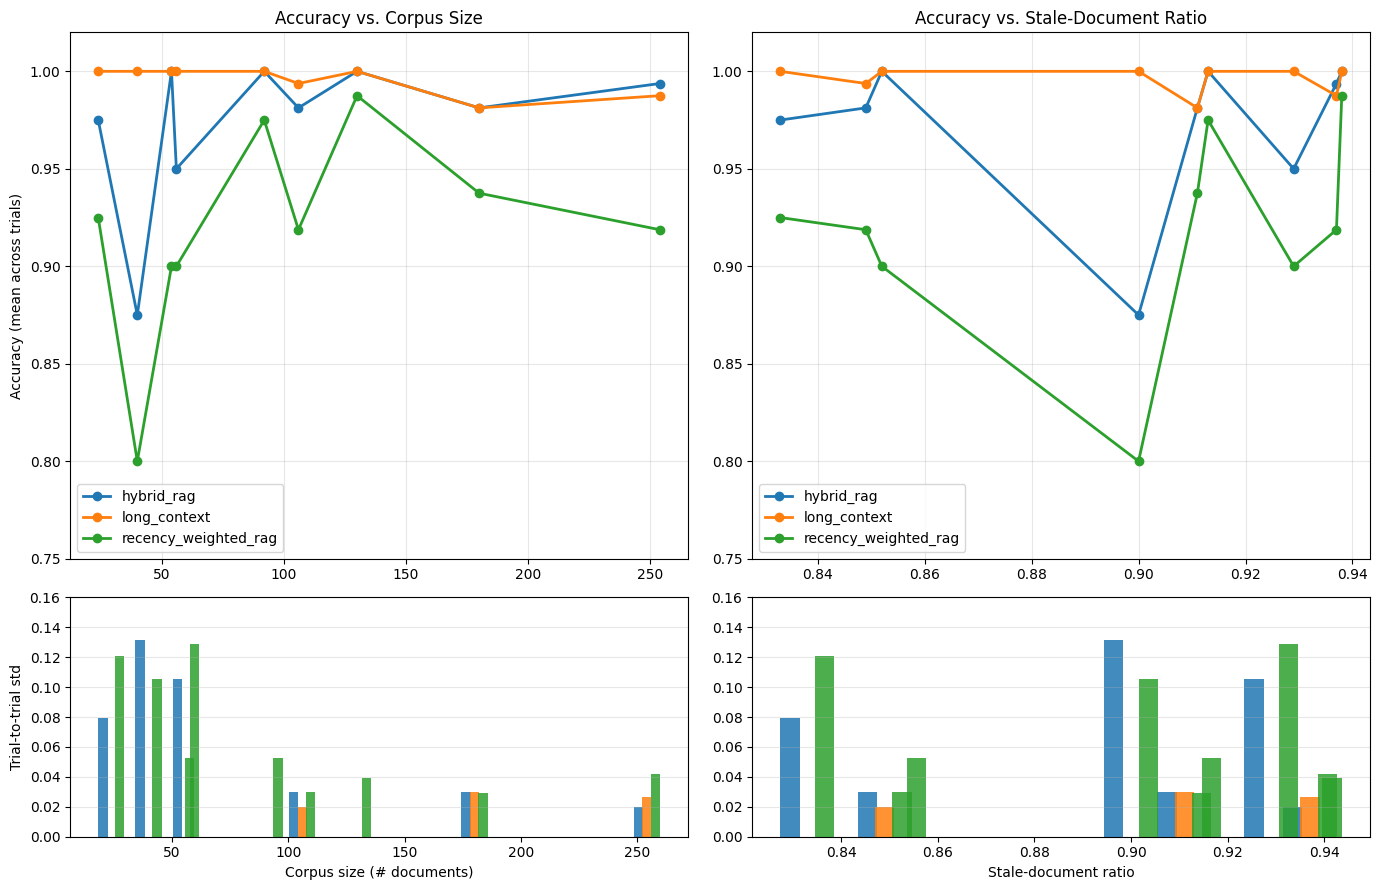

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# summary is your trial-variance-by-config dataframe
COLORS = {"hybrid_rag": "#1f77b4", "long_context": "#ff7f0e", "recency_weighted_rag": "#2ca02c"}

fig, axes = plt.subplots(2, 2, figsize=(14, 9), height_ratios=[2.2, 1])

# TOP ROW: accuracy lines only, zoomed y-axis, no overlapping bands
for col, xcol, title in [
    (0, "corpus_size", "Accuracy vs. Corpus Size"),
    (1, "stale_ratio", "Accuracy vs. Stale-Document Ratio"),
]:
    ax = axes[0, col]
    for condition, g in summary.groupby("condition"):
        g = g.sort_values(xcol)
        ax.plot(g[xcol], g["accuracy_mean"], marker='o', label=condition,
                color=COLORS[condition], linewidth=2, markersize=6)
    ax.set_ylabel("Accuracy (mean across trials)" if col == 0 else "")
    ax.set_title(title)
    ax.set_ylim(0.75, 1.02)
    ax.legend(loc="lower left")
    ax.grid(alpha=0.3)

# BOTTOM ROW: trial-to-trial std as grouped bars, not overlapping fills
for col, xcol, xlabel in [
    (0, "corpus_size", "Corpus size (# documents)"),
    (1, "stale_ratio", "Stale-document ratio"),
]:
    ax = axes[1, col]
    conditions = sorted(summary["condition"].unique())
    x_vals = sorted(summary[xcol].unique())
    width = (x_vals[1] - x_vals[0]) * 0.25 if len(x_vals) > 1 else 5
    for i, condition in enumerate(conditions):
        g = summary[summary["condition"] == condition].sort_values(xcol)
        offset = (i - 1) * width * 0.9
        ax.bar(g[xcol].values + offset, g["accuracy_std"].values, width=width,
               color=COLORS[condition], alpha=0.85, label=condition)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Trial-to-trial std" if col == 0 else "")
    ax.set_ylim(0, 0.16)
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("accuracy_clean.png", dpi=150)
plt.show()

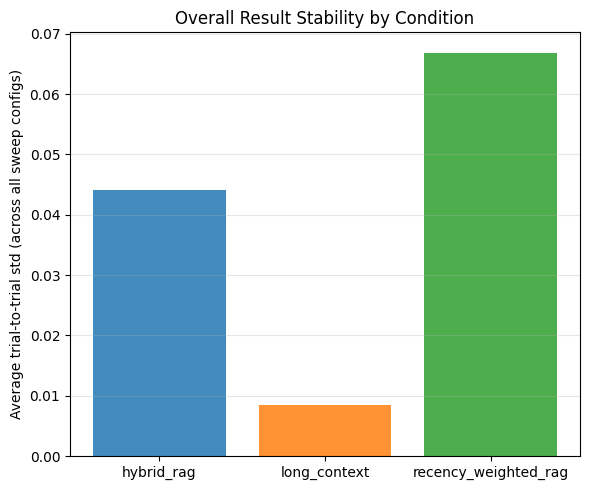

In [ ]:
import matplotlib.pyplot as plt

cond_std = summary.groupby("condition")["accuracy_std"].mean().reindex(
    ["hybrid_rag", "long_context", "recency_weighted_rag"]
)

fig, ax = plt.subplots(figsize=(6, 5))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
ax.bar(cond_std.index, cond_std.values, color=colors, alpha=0.85)
ax.set_ylabel("Average trial-to-trial std (across all sweep configs)")
ax.set_title("Overall Result Stability by Condition")
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("stability_three_bars.png", dpi=150)
plt.show()

##ANALYTICS: RETRIEVAL vs GENERATION  

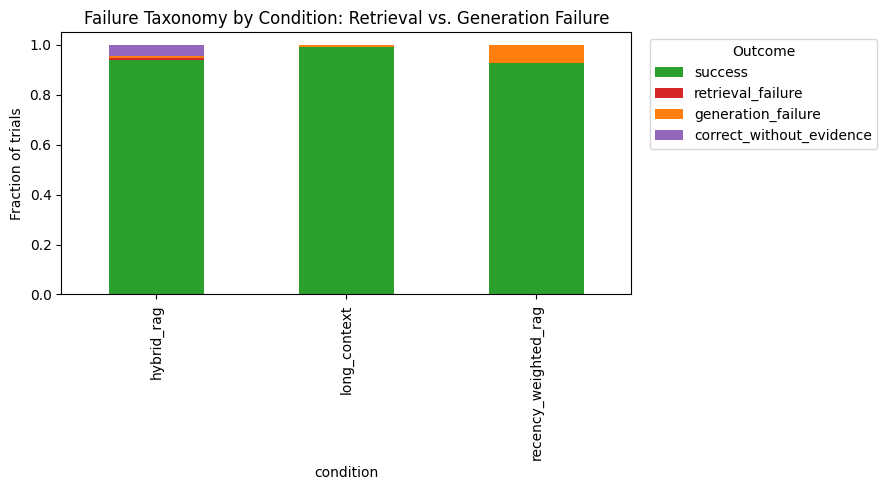

LEGEND
retrieval_failure: The current/correct document never reached the model blame the RETRIEVER, not the generator.
generation_failure: The current document WAS in context, but the model still answered wrong (e.g. distracted by a contradiction doc or many stale paraphrases);
                              blame the GENERATOR/prompt, not the retriever.
correct_without_evidence: Answer happened to be correct even though the
                              current doc wasn't retrieved (likely parametric
                              knowledge leakage from pretraining, not grounded).
  success: current doc available AND correctly used.


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
taxonomy_order = ["success", "retrieval_failure", "generation_failure", "correct_without_evidence"]
pivot = (results_df.groupby(["condition", "failure_type"]).size()
         .unstack(fill_value=0))
pivot = pivot.reindex(columns=[c for c in taxonomy_order if c in pivot.columns], fill_value=0)
pivot_frac = pivot.div(pivot.sum(axis=1), axis=0)

pivot_frac.plot(kind="bar", stacked=True, ax=ax,
                 color=["#2ca02c", "#d62728", "#ff7f0e", "#9467bd"])
ax.set_ylabel("Fraction of trials")
ax.set_title("Failure Taxonomy by Condition: Retrieval vs. Generation Failure")
ax.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("rag_vs_longcontext_failure_taxonomy.png", dpi=150)
plt.show()

print("LEGEND")
print("retrieval_failure: The current/correct document never reached the model blame the RETRIEVER, not the generator.")
print("generation_failure: The current document WAS in context, but the model still answered wrong (e.g. distracted by a contradiction doc or many stale paraphrases);")
print("                              blame the GENERATOR/prompt, not the retriever.")
print("correct_without_evidence: Answer happened to be correct even though the")
print("                              current doc wasn't retrieved (likely parametric")
print("                              knowledge leakage from pretraining, not grounded).")
print("  success: current doc available AND correctly used.")